In [31]:
import pandas as pd
import os
import numpy as np

df = pd.read_csv("Heart_Disease_Prediction.csv")

In [45]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [44]:
print ("Rows: ", df.shape[0]\
      ,"\nColumns: ", df.shape[1]\
      ,"\nFeatures: ", df.columns.tolist()\
      ,"\nData Types: \n", df.dtypes,\
    sep='')

Rows: 270
Columns: 14
Features: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
Data Types: 
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object


In [63]:
stats_df = df.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']
stats_df.rename ({'50%':'median'}, inplace=True)

fields = ["mean", "25%", "median", "75%", "range"]
stats_df = stats_df.loc[fields]

stats_df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.32963,1.05,1.585185,0.67037,4.696296
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.00000,0.00,1.000000,0.00000,3.000000
median,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.00000,0.80,2.000000,0.00000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.00000,1.60,2.000000,1.00000,7.000000
range,48.000000,1.000000,3.000000,106.000000,438.000000,1.000000,2.000000,131.000000,1.00000,6.20,2.000000,3.00000,4.000000


In [64]:
df["Chest pain type"].value_counts()

Chest pain type
4    129
3     79
2     42
1     20
Name: count, dtype: int64

In [78]:
agg_dict = {field: ["mean", "median"] for field in df.columns if df[field].dtype in [np.int64, np.float64]}
agg_dict['Age'] = 'min'

df.groupby("Heart Disease").agg(agg_dict)

Age       Sex         ... Number of vessels fluro  Thallium       
              min      mean median  ...                  median      mean median
Heart Disease                       ...                                         
Absence        29  0.553333    1.0  ...                     0.0  3.786667    3.0
Presence       35  0.833333    1.0  ...                     1.0  5.833333    7.0

[2 rows x 25 columns]

In [79]:
import matplotlib.pyplot as plt

[Text(0.5, 0, 'Age'),
 Text(0, 0.5, 'BP'),
 Text(0.5, 1.0, 'Age vs BP Scatter Plot')]

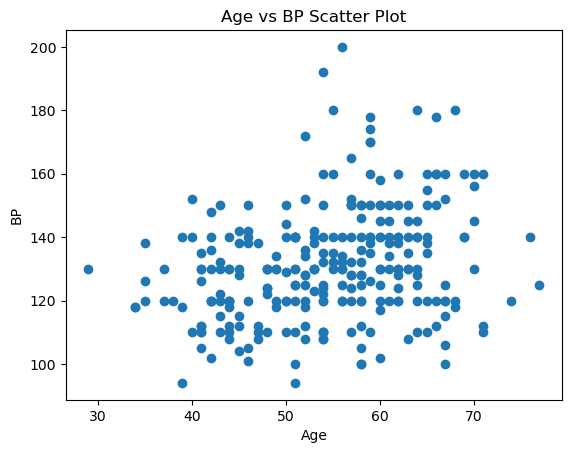

In [83]:
ax = plt.axes()
ax.scatter(df.Age, df.BP)
ax.set(xlabel='Age', ylabel='BP', title='Age vs BP Scatter Plot')

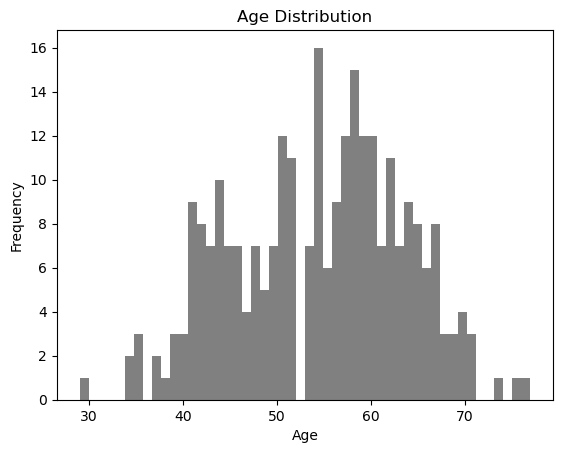

In [90]:
ax = plt.axes()
ax.hist(df['Age'], bins=50, color='grey')
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
plt.show()


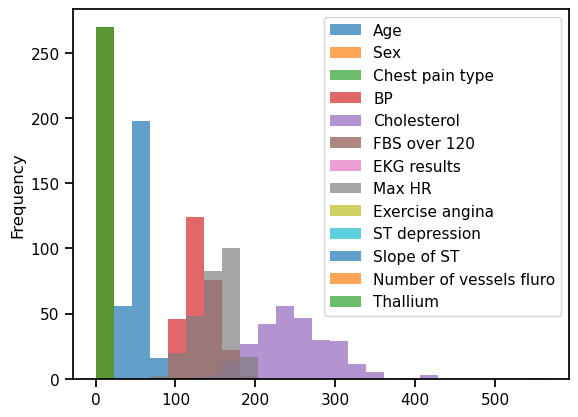

In [97]:
import seaborn as sns
sns.set_context('notebook')
ax = df.plot.hist(bins=25, alpha=0.7)

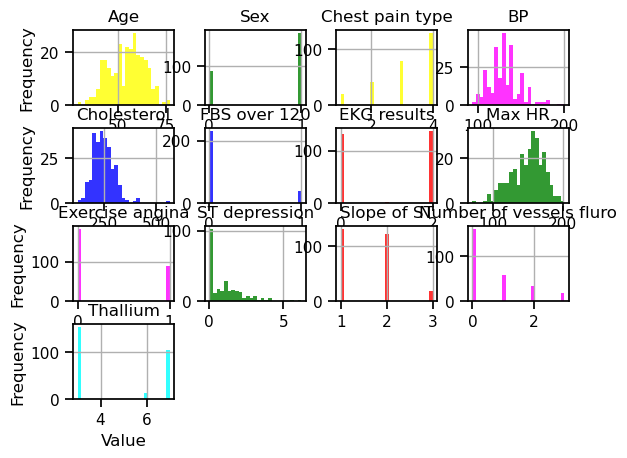

In [112]:
import random

colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow']

axList = df.hist(bins=25, alpha=0.8)
for ax in axList.flatten():

    color = random.choice(colors)

    for patch in ax.patches:
        patch.set_facecolor(color)

    spec = ax.get_subplotspec()

    ax.set_xlabel("")
    ax.set_ylabel("")

    if spec.is_last_row():
        ax.set_xlabel("Value")

    if spec.is_first_col():
        ax.set_ylabel("Frequency")




In [132]:
plot_data = (df.set_index('Heart Disease').stack().to_frame().reset_index().rename(columns={0: 'Value'}))
plot_data = plot_data.rename(columns={'level_1': 'Data Type'})
plot_data.head()

,Heart Disease,Data Type,Value
0,Presence,Age,70.0
1,Presence,Sex,1.0
2,Presence,Chest pain type,4.0
3,Presence,BP,130.0
4,Presence,Cholesterol,322.0


<Axes: xlabel='Data Type', ylabel='Value'>

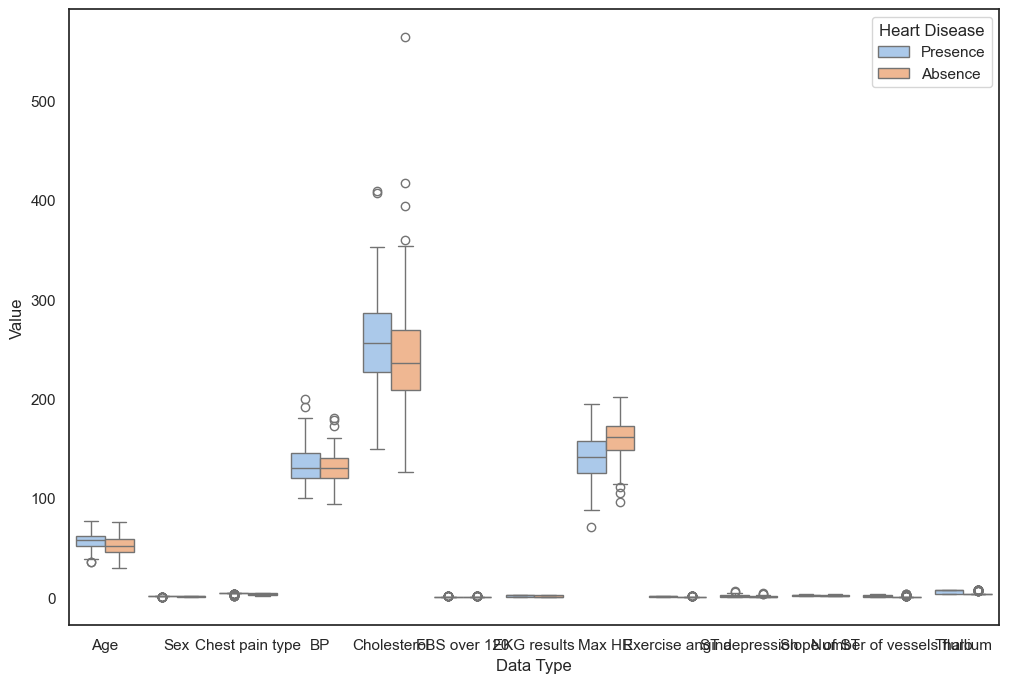

In [ ]:
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('pastel')

f = plt.figure(figsize=(12, 8))
sns.boxplot(x='Data Type', y='Value', hue='Heart Disease', data=plot_data)

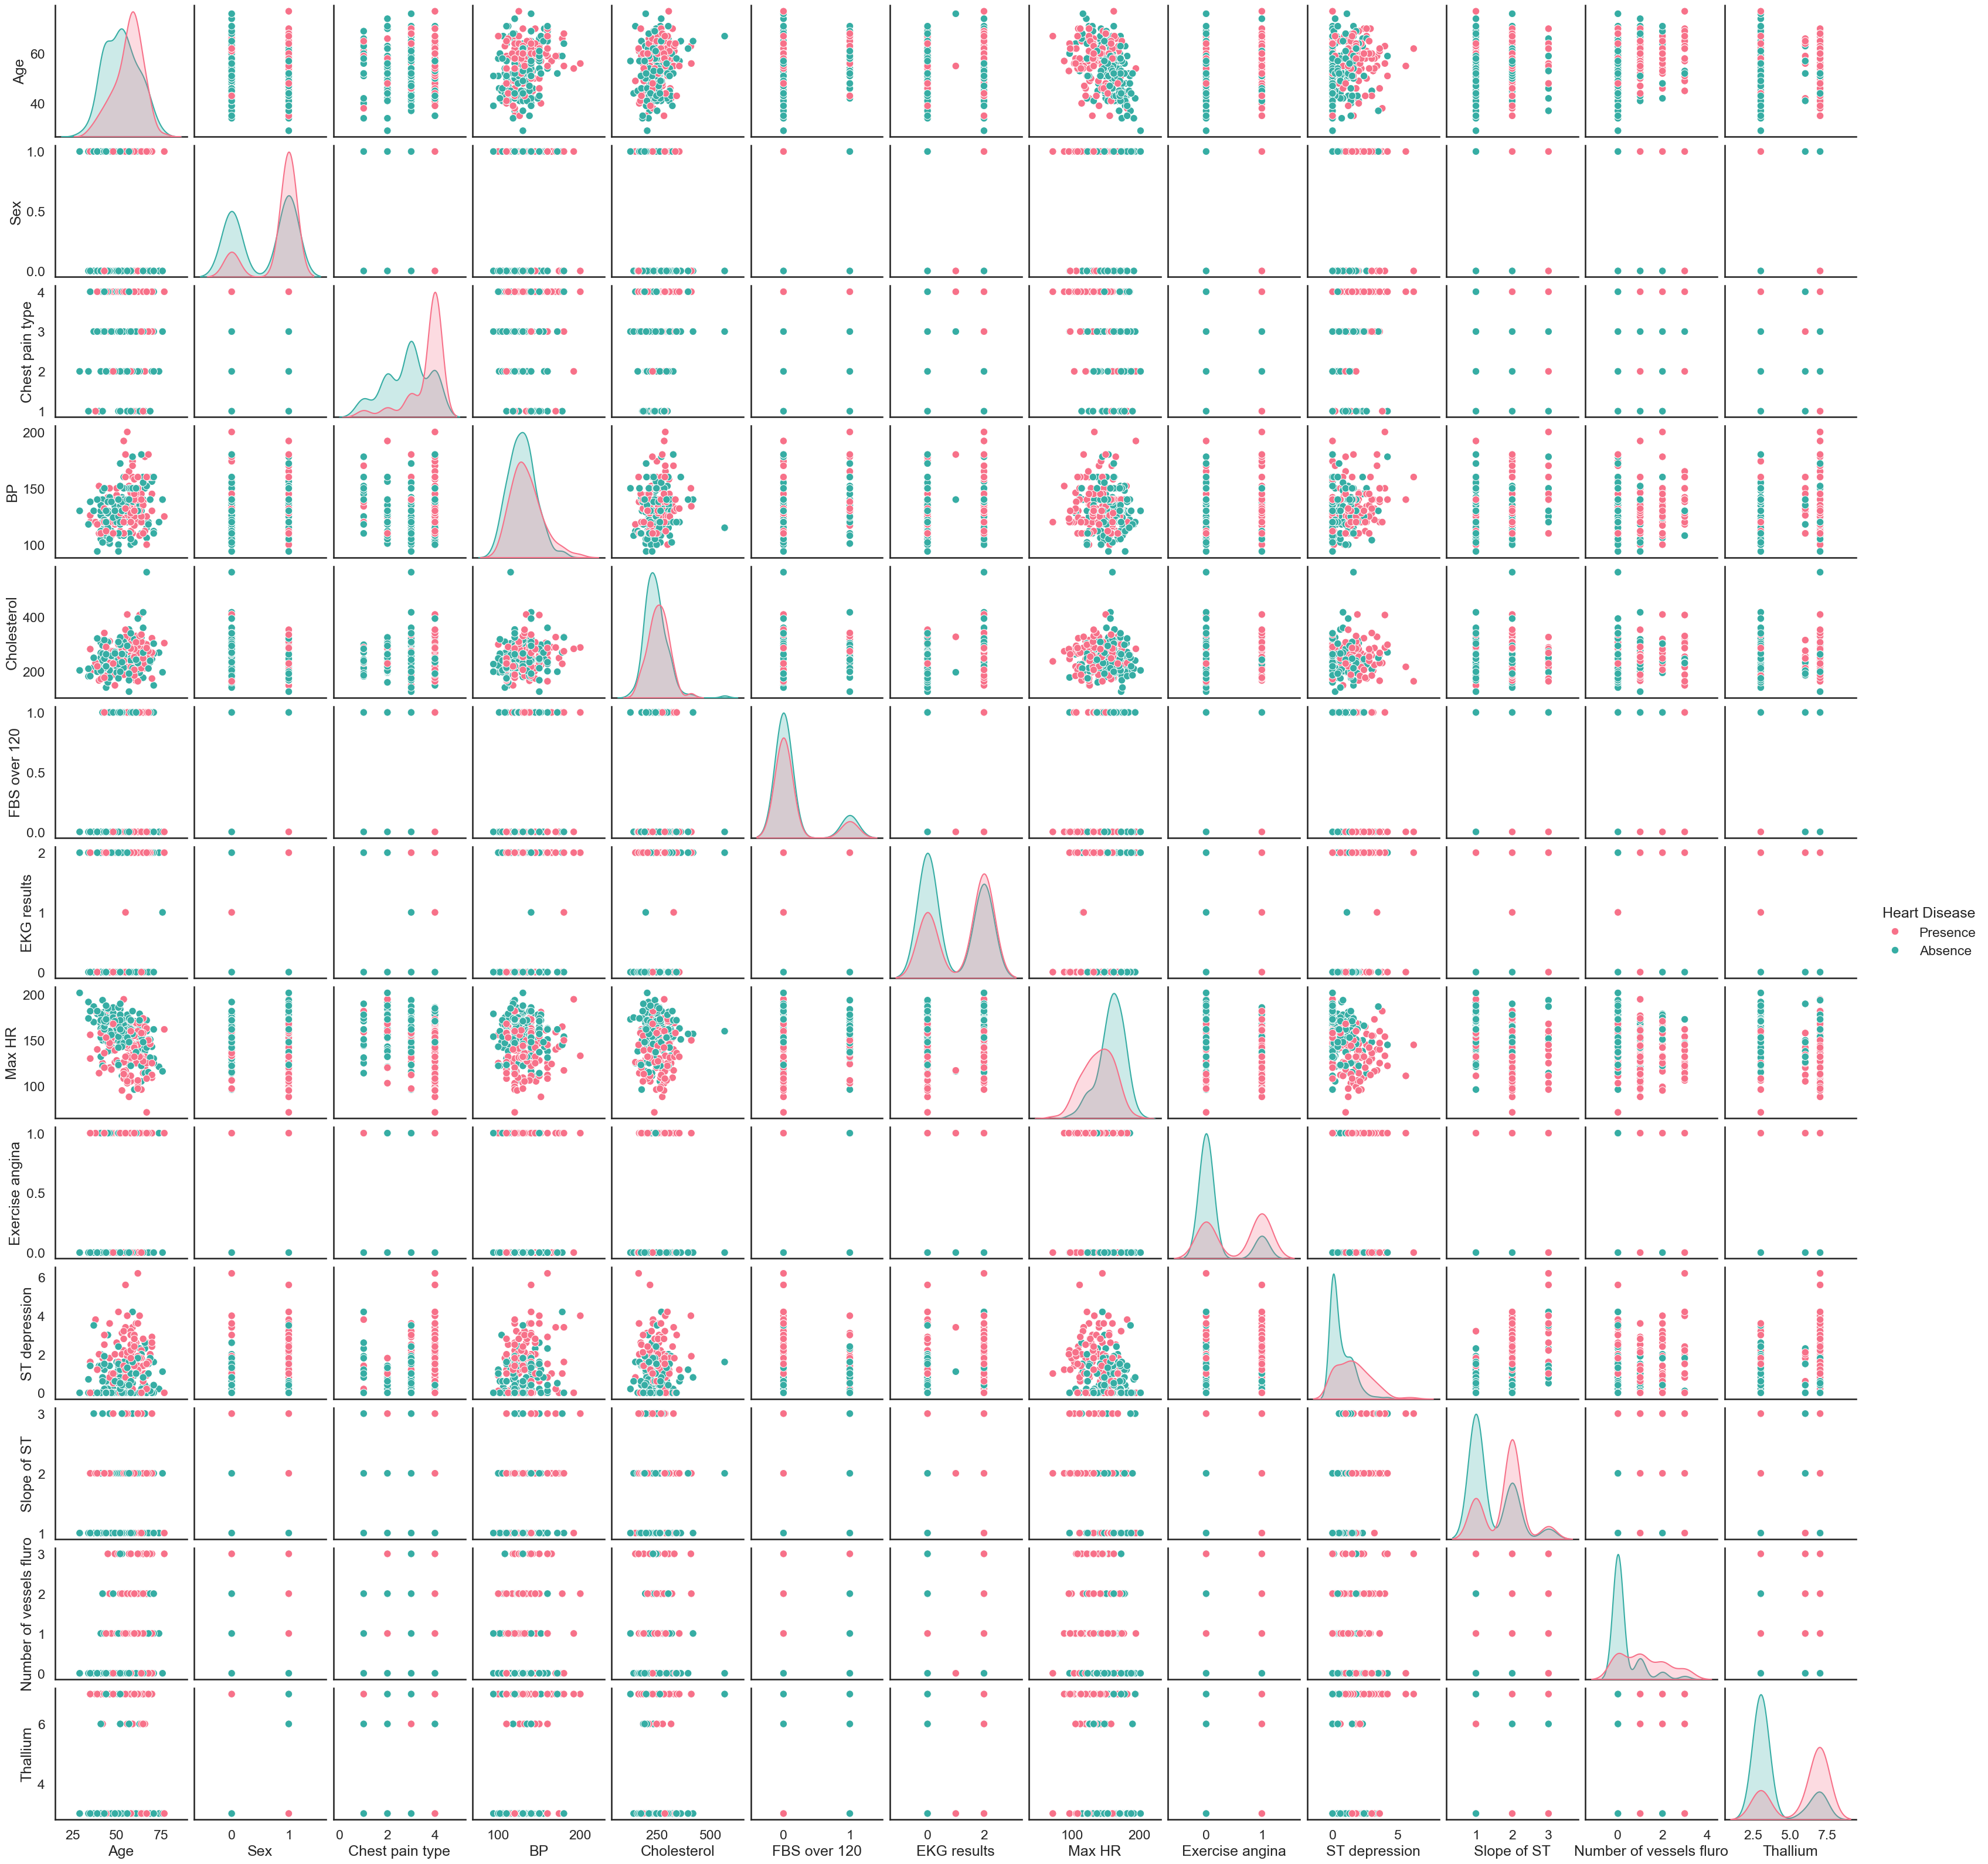

In [135]:
sns.set_context('talk')
sns.pairplot(df, hue='Heart Disease', diag_kind='kde', palette='husl')